https://www.microsoft.com/en-us/research/wp-content/uploads/2016/02/SoftRankWsdm08Submitted.pdf

In [11]:
import torch
import math
import seaborn as sns

In [12]:
def gaussian_cdf(value, loc, scale):
    return 0.5 * (1 + torch.erf((value - loc) * scale.reciprocal() / math.sqrt(2)))

In [13]:
def gaussian_survival_function(value, loc, scale):
    return 1 - gaussian_cdf(value, loc, scale)

In [14]:
# equation (10) in the paper https://www.microsoft.com/en-us/research/wp-content/uploads/2016/02/SoftRankWsdm08Submitted.pdf
def expected_ranks(predicted_potential, predicted_scale=None):
    delta = predicted_potential.view(-1, 1) - predicted_potential.view(1, -1)
    if predicted_scale is None:
        scale = torch.ones(1)
    else:
        assert predicted_scale.size() == predicted_potential.size()
        scale = predicted_scale.view(-1, 1) + predicted_scale.view(1, -1)
        assert predicted_scale.size() == delta.size()

    # Pr[rank(i) > rank(j)] (equation 9)
    pij = gaussian_survival_function(torch.zeros(1), delta, scale)
    # Equation 10
    return (1 - pij).sum(dim=1)


def soft_spearman(pred_scores, target_rank):
    soft_ranks = expected_ranks(pred_scores)
    assert soft_ranks.size(0) == target_rank.size(0)
    n = target_rank.size(0)
    target_rank = target_rank.view(soft_ranks.size())
    d = soft_ranks - target_rank
    return 1 - 6 * (d * d).sum() / (n * (n * n - 1))

In [15]:
def fit(params, criterion):
    opt = torch.optim.Adam([params], lr=0.01)
    for i in range(1000):
        opt.zero_grad()
        loss = criterion(params)
        loss.backward()
        opt.step()
        if i % 100 == 0:
            print(loss.item())
    return params

In [16]:
potential = torch.randn(6, requires_grad=True)
potential

tensor([ 0.5195,  1.9017,  2.1237,  0.9083, -0.4671,  1.4509],
       requires_grad=True)

In [17]:
target_rank = torch.arange(6).float()
target_rank

tensor([0., 1., 2., 3., 4., 5.])

Text(0.5, 1.0, 'Initial potential vs target rank')

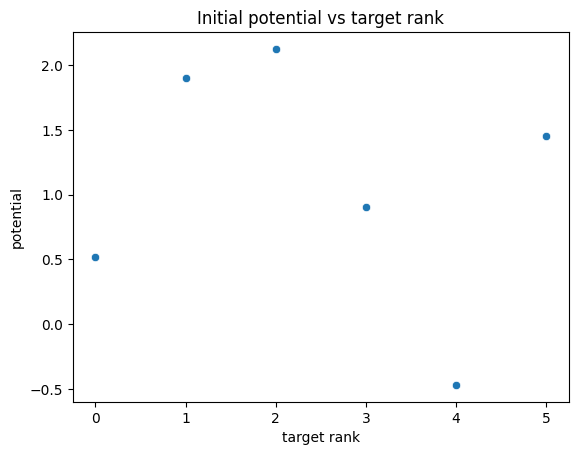

In [ ]:
ax = sns.scatterplot(x=target_rank.numpy(), y=potential.detach().numpy())
ax.set_xlabel("target rank (higher is better)")
ax.set_ylabel("potential")
ax.set_title("Initial potential vs target rank")

In [19]:
fit(potential, lambda scores: -soft_spearman(scores, target_rank))

-0.2816019654273987
-0.8208367228507996
-0.9134981632232666
-0.9325776100158691
-0.9405257701873779
-0.9448249936103821
-0.9474945664405823
-0.9493013024330139
-0.9505987167358398
-0.951571524143219


tensor([ 2.9013,  2.0611,  1.3043,  0.5819, -0.1740, -1.0109],
       requires_grad=True)

Text(0.5, 1.0, 'Fitted potential vs target rank')

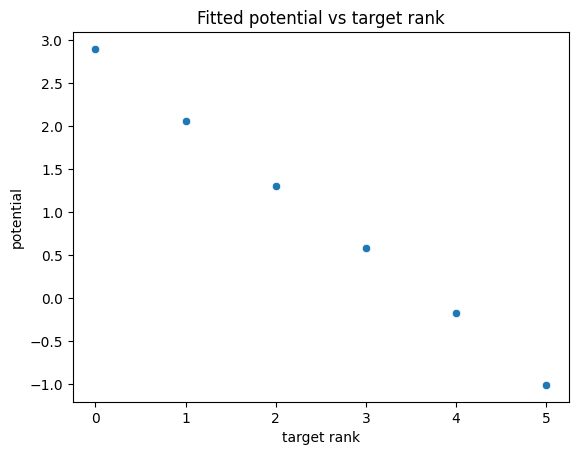

In [ ]:
ax = sns.scatterplot(x=target_rank.numpy(), y=potential.detach().numpy())
ax.set_xlabel("target rank (higher is better)")
ax.set_ylabel("potential")
ax.set_title("Fitted potential vs target rank")